In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from astropy import units as u 
from astropy import constants as const 

In [4]:
df = pd.read_csv("solar_system.csv")
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [5]:
df.shape

#20 rows and 11 columns before transposing 

(20, 11)

In [6]:
df = df.set_index("Attribute").T
df.index.name = "Planet"
df.reset_index(inplace = True)
df.columns.name = None

In [7]:
df.shape

#10 rows and 21 columns after transposing 

(10, 21)

In [11]:
temp = pd.read_csv("solar_system.csv")

temp = temp.set_index("Attribute")
print(temp.shape)

temp = temp.T
print(temp.shape)

temp.index.name = "Planet"
temp.reset_index(inplace=True)
print(temp.shape)


#set_index --> makes "Attribute" the row labels 
#index.name --> renames index to Planet
#reset_index --> turns index into a column 
#columns.name --> removes column label name 

(20, 10)
(10, 20)
(10, 21)


In [ ]:
#The shape is not (11, 20) because the dataframe was not only transposed
#Before transposing, the "attribute" column was set as the index, removing it from the column count and changing the strucutre of the dataframe
#After transposing, the index becomes the columns, and then we also added a new column
#So the dimensions change as a whole, and it wasn't just a row-column swap

In [12]:
print(df.columns)

Index(['Planet', 'Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)',
       'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)',
       'Length of Day (hours)', 'Distance from Sun (10^6 km)',
       'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)',
       'Orbital Velocity (km/s)', 'Orbital Inclination (deg)',
       'Orbital Eccentricity', 'Obliquity to Orbit (deg)',
       'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons',
       'Ring System?', 'Global Magnetic Field?'],
      dtype='object')


In [15]:
columns_with_units = [col for col in df.columns if "(" in col]
columns_without_units = [col for col in df.columns if "(" not in col]

print("Columns with units:", columns_with_units)
print("Count:", len(columns_with_units))

print("\nColumns without units:", columns_without_units)
print("Count:", len(columns_without_units))

Columns with units: ['Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)', 'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)', 'Length of Day (hours)', 'Distance from Sun (10^6 km)', 'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)', 'Orbital Velocity (km/s)', 'Orbital Inclination (deg)', 'Obliquity to Orbit (deg)', 'Mean Temperature (C)', 'Surface Pressure (bars)']
Count: 16

Columns without units: ['Planet', 'Orbital Eccentricity', 'Number of Moons', 'Ring System?', 'Global Magnetic Field?']
Count: 5


In [16]:
df

,Planet,Mass (10^24kg),Diameter (km),Density (kg/m^3),Gravity (m/s^2),Escape Velocity (km/s),Rotation Period (hours),Length of Day (hours),Distance from Sun (10^6 km),Perihelion (10^6 km),...,Orbital Period (days),Orbital Velocity (km/s),Orbital Inclination (deg),Orbital Eccentricity,Obliquity to Orbit (deg),Mean Temperature (C),Surface Pressure (bars),Number of Moons,Ring System?,Global Magnetic Field?
0,Mercury,0.330,4879,5429,3.7,4.3,1407.6,4222.6,57.9,46.0,...,88.0,47.4,7.0,0.206,0.034,167,0,0,No,Yes
1,Venus,4.87,12104,5243,8.9,10.4,-5832.5,2802.0,108.2,107.5,...,224.7,35.0,3.4,0.007,177.4,464,92,0,No,No
2,Earth,5.97,12756,5514,9.8,11.2,23.9,24.0,149.6,147.1,...,365.2,29.8,0.0,0.017,23.4,15,1,1,No,Yes
3,Moon,0.073,3475,3340,1.6,2.4,655.7,708.7,0.384,0.363,...,27.3,1.0,5.1,0.055,6.7,-20,0,0,No,No
4,Mars,0.642,6792,3934,3.7,5.0,24.6,24.7,228.0,206.7,...,687.0,24.1,1.8,0.094,25.2,-65,0.01,2,No,No
5,Jupiter,1898,142984,1326,23.1,59.5,9.9,9.9,778.5,740.6,...,4331,13.1,1.3,0.049,3.1,-110,Unknown,95,Yes,Yes
6,Saturn,568,120536,687,9.0,35.5,10.7,10.7,1432.0,1357.6,...,10747,9.7,2.5,0.052,26.7,-140,Unknown,274,Yes,Yes
7,Uranus,86.8,51118,1270,8.7,21.3,-17.2,17.2,2867.0,2732.7,...,30589,6.8,0.8,0.047,97.8,-195,Unknown,28,Yes,Yes
8,Neptune,102,49528,1638,11.0,23.5,16.1,16.1,4515.0,4471.1,...,59800,5.4,1.8,0.010,28.3,-200,Unknown,16,Yes,Yes
9,Pluto,0.0130,2376,1850,0.7,1.3,-153.3,153.3,5906.4,4436.8,...,90560,4.7,17.2,0.244,119.5,-225,0.00001,5,No,Unknown


In [17]:
df.dtypes

Planet                         object
Mass (10^24kg)                 object
Diameter (km)                  object
Density (kg/m^3)               object
Gravity (m/s^2)                object
Escape Velocity (km/s)         object
Rotation Period (hours)        object
Length of Day (hours)          object
Distance from Sun (10^6 km)    object
Perihelion (10^6 km)           object
Aphelion (10^6 km)             object
Orbital Period (days)          object
Orbital Velocity (km/s)        object
Orbital Inclination (deg)      object
Orbital Eccentricity           object
Obliquity to Orbit (deg)       object
Mean Temperature (C)           object
Surface Pressure (bars)        object
Number of Moons                object
Ring System?                   object
Global Magnetic Field?         object
dtype: object

In [18]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].apply(type).value_counts())


Column: Planet
Planet
<class 'str'>    10
Name: count, dtype: int64

Column: Mass (10^24kg)
Mass (10^24kg)
<class 'str'>    10
Name: count, dtype: int64

Column: Diameter (km)
Diameter (km)
<class 'str'>    10
Name: count, dtype: int64

Column: Density (kg/m^3)
Density (kg/m^3)
<class 'str'>    10
Name: count, dtype: int64

Column: Gravity (m/s^2)
Gravity (m/s^2)
<class 'str'>    10
Name: count, dtype: int64

Column: Escape Velocity (km/s)
Escape Velocity (km/s)
<class 'str'>    10
Name: count, dtype: int64

Column: Rotation Period (hours)
Rotation Period (hours)
<class 'str'>    10
Name: count, dtype: int64

Column: Length of Day (hours)
Length of Day (hours)
<class 'str'>    10
Name: count, dtype: int64

Column: Distance from Sun (10^6 km)
Distance from Sun (10^6 km)
<class 'str'>    10
Name: count, dtype: int64

Column: Perihelion (10^6 km)
Perihelion (10^6 km)
<class 'str'>    10
Name: count, dtype: int64

Column: Aphelion (10^6 km)
Aphelion (10^6 km)
<class 'str'>    10
Name: cou

In [ ]:
#(a) The actual values are mostly strings
#(b) Storing numerical values as strings is a problem because mathematical operations cannot be performed correctly
#For example, you cannot compute averages, sums, or comparisons on strings, which makes proper data analysis harder

In [21]:
exclude_cols = ["Planets", "Ring System?", "Global Magnetic Field?"]

for col in df.columns:
    if col not in exclude_cols:
        df[col] = pd.to_numeric(df[col], errors = "coerce")

In [22]:
df.dtypes

Planet                         float64
Mass (10^24kg)                 float64
Diameter (km)                    int64
Density (kg/m^3)                 int64
Gravity (m/s^2)                float64
Escape Velocity (km/s)         float64
Rotation Period (hours)        float64
Length of Day (hours)          float64
Distance from Sun (10^6 km)    float64
Perihelion (10^6 km)           float64
Aphelion (10^6 km)             float64
Orbital Period (days)          float64
Orbital Velocity (km/s)        float64
Orbital Inclination (deg)      float64
Orbital Eccentricity           float64
Obliquity to Orbit (deg)       float64
Mean Temperature (C)             int64
Surface Pressure (bars)        float64
Number of Moons                  int64
Ring System?                    object
Global Magnetic Field?          object
dtype: object

In [ ]:
#(a) float64, int64, and object
#(b) float64 = decimal numbers, int64 = integer numbers, object = non-numerical data 
#(c) Ring System and Global Magnetic Field are still objects because it contains Yes/No answers (text) instead of numerical values

In [23]:
def attach_units(df, old_col, new_col, unit):
    new_values = []

    for val in df[old_col]:
        new_values.append(val * unit)

    df[old_col] = new_values
    df.rename(columns = {old_col: new_col}, inplace = True)

In [26]:
u.bar 

attach_units(
    df, 
    old_col="Surface Pressure (bars)",
    new_col="Surface Pressure (bars)",
    unit=u.bar
)

df["Surface Pressure (bars)"]

0      0.0 bar
1     92.0 bar
2      1.0 bar
3      0.0 bar
4     0.01 bar
5      nan bar
6      nan bar
7      nan bar
8      nan bar
9    1e-05 bar
Name: Surface Pressure (bars), dtype: object

In [32]:
for col in df.columns:
    print(col)

semi_major = (df["Perihelion (10^6 km)"] + df["Aphelion (10^6 km)"]) / 2
aphelion_index = df.columns.get_loc("Aphelion (10^6 km)")
df.insert(aphelion_index + 1, "Semi-Major Axis (10^6 km)", semi_major)

print(df.columns)
print(df["Semi-Major Axis (10^6 km)"])

Planet
Mass (10^24kg)
Diameter (km)
Density (kg/m^3)
Gravity (m/s^2)
Escape Velocity (km/s)
Rotation Period (hours)
Length of Day (hours)
Distance from Sun (10^6 km)
Perihelion (10^6 km)
Aphelion (10^6 km)
Orbital Period (days)
Orbital Velocity (km/s)
Orbital Inclination (deg)
Orbital Eccentricity
Obliquity to Orbit (deg)
Mean Temperature (C)
Surface Pressure (bars)
Number of Moons
Ring System?
Global Magnetic Field?
Index(['Planet', 'Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)',
       'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)',
       'Length of Day (hours)', 'Distance from Sun (10^6 km)',
       'Perihelion (10^6 km)', 'Aphelion (10^6 km)',
       'Semi-Major Axis (10^6 km)', 'Orbital Period (days)',
       'Orbital Velocity (km/s)', 'Orbital Inclination (deg)',
       'Orbital Eccentricity', 'Obliquity to Orbit (deg)',
       'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons',
       'Ring System?', 'Global Magnetic Field?'],
  

In [38]:
df

,Planet,Mass (10^24kg),Diameter (km),Density (kg/m^3),Gravity (m/s^2),Escape Velocity (km/s),Rotation Period (hours),Length of Day (hours),Distance from Sun (10^6 km),Perihelion (10^6 km),...,Orbital Velocity (km/s),Orbital Inclination (deg),Orbital Eccentricity,Obliquity to Orbit (deg),Mean Temperature (C),Surface Pressure (bars),Number of Moons,Ring System?,Global Magnetic Field?,Orbital Period (years)
0,NaN,0.330,4879,5429,3.7,4.3,1407.6,4222.6,57.900,46.000,...,47.4,7.0,0.206,0.034,167,0.0 bar,0,No,Yes,0.24093086926762491 yr
1,NaN,4.870,12104,5243,8.9,10.4,-5832.5,2802.0,108.200,107.500,...,35.0,3.4,0.007,177.400,464,92.0 bar,0,No,No,0.6151950718685831 yr
2,NaN,5.970,12756,5514,9.8,11.2,23.9,24.0,149.600,147.100,...,29.8,0.0,0.017,23.400,15,1.0 bar,1,No,Yes,0.9998631074606433 yr
3,NaN,0.073,3475,3340,1.6,2.4,655.7,708.7,0.384,0.363,...,1.0,5.1,0.055,6.700,-20,0.0 bar,0,No,No,0.07474332648870637 yr
4,NaN,0.642,6792,3934,3.7,5.0,24.6,24.7,228.000,206.700,...,24.1,1.8,0.094,25.200,-65,0.01 bar,2,No,No,1.8809034907597535 yr
5,NaN,1898.000,142984,1326,23.1,59.5,9.9,9.9,778.500,740.600,...,13.1,1.3,0.049,3.100,-110,nan bar,95,Yes,Yes,11.85763175906913 yr
6,NaN,568.000,120536,687,9.0,35.5,10.7,10.7,1432.000,1357.600,...,9.7,2.5,0.052,26.700,-140,nan bar,274,Yes,Yes,29.423682409308693 yr
7,NaN,86.800,51118,1270,8.7,21.3,-17.2,17.2,2867.000,2732.700,...,6.8,0.8,0.047,97.800,-195,nan bar,28,Yes,Yes,83.74811772758385 yr
8,NaN,102.000,49528,1638,11.0,23.5,16.1,16.1,4515.000,4471.100,...,5.4,1.8,0.010,28.300,-200,nan bar,16,Yes,Yes,163.72347707049965 yr
9,NaN,0.013,2376,1850,0.7,1.3,-153.3,153.3,5906.400,4436.800,...,4.7,17.2,0.244,119.500,-225,1e-05 bar,5,No,Unknown,247.93976728268308 yr


In [48]:
df = pd.read_csv("solar_system.csv")

df = df.set_index("Attribute").T
df.index.name = "Planet"
df.reset_index(inplace=True)
df.columns.name = None

exclude_cols = ["Planet", "Ring System?", "Global Magnetic Field?"]

for col in df.columns:
    if col not in exclude_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [49]:
if "Orbital Period (days)" in df.columns:
    df["Orbital Period (years)"] = [(val * u.day).to(u.yr) for val in df["Orbital Period (days)"]]
    df.drop(columns=["Orbital Period (days)"], inplace=True)

print(df["Orbital Period (years)"])

favorite = df.loc[df["Planet"].str.strip() == "Neptune", "Orbital Period (years)"].iloc[0]
print(f"Neptune's orbital period is {favorite.value:.4f} {favorite.unit}")

0    0.24093086926762491 yr
1     0.6151950718685831 yr
2     0.9998631074606433 yr
3    0.07474332648870637 yr
4     1.8809034907597535 yr
5      11.85763175906913 yr
6     29.423682409308693 yr
7      83.74811772758385 yr
8     163.72347707049965 yr
9     247.93976728268308 yr
Name: Orbital Period (years), dtype: object
Neptune's orbital period is 163.7235 yr


In [50]:
#AU = an astronomical unit, which is the distance between the Earth and the Sun used to measure distances within our solar system

print(const.au)

  Name   = Astronomical Unit
  Value  = 149597870700.0
  Uncertainty  = 0.0
  Unit  = m
  Reference = IAU 2012 Resolution B2


In [51]:
print(const.au.to(u.km))

149597870.70000002 km


In [52]:
km_cols = [col for col in df.columns if "km" in col]
print(km_cols)

['Diameter (km)', 'Escape Velocity (km/s)', 'Distance from Sun (10^6 km)', 'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Velocity (km/s)']


In [53]:
for col in km_cols:
    new_col = col.replace("km", "AU")
    df[new_col] = [(val * u.km).to(u.AU) if not hasattr(val, "unit") else val.to(u.AU) for val in df[col]]
    df.drop(columns=[col], inplace=True)

In [55]:
neptune_row = df[df["Planet"] == "Neptune"].iloc[0]

for col in df.columns:
    if "AU" in col:
        print(col, ":", neptune[col])

Diameter (AU) : 0.0003310742309917116 AU
Escape Velocity (AU/s) : 1.5708779737330848e-07 AU
Distance from Sun (10^6 AU) : 3.0180910857042032e-05 AU
Perihelion (10^6 AU) : 2.988745748237445e-05 AU
Aphelion (10^6 AU) : 3.0474364231709616e-05 AU
Orbital Velocity (AU/s) : 3.609677046024961e-08 AU


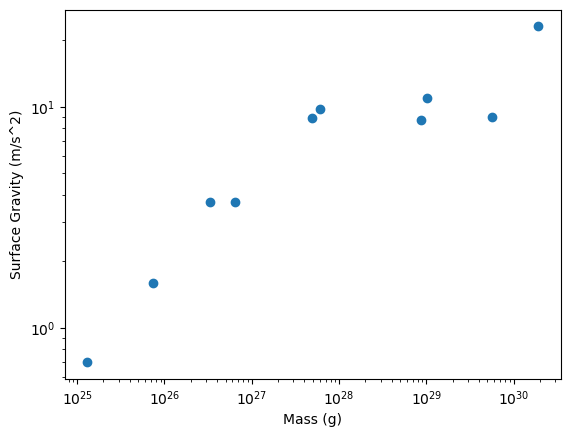

In [57]:
mass_g = [
    (val * 1e24 * u.kg).to(u.g).value if not hasattr(val, "unit")
    else val.to(u.g).value
    for val in df["Mass (10^24kg)"]
]

gravity = [
    val.to(u.m / u.s**2).value if hasattr(val, "unit")
    else val
    for val in df["Gravity (m/s^2)"]
]

plt.figure()
plt.scatter(mass_g, gravity)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mass (g)")
plt.ylabel("Surface Gravity (m/s^2)")
plt.show()

In [58]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

Best fit parameters:
m = 0.2416184632394755
b = -5.968369855331557
Reduced chi-squared = 0.03536864165577379


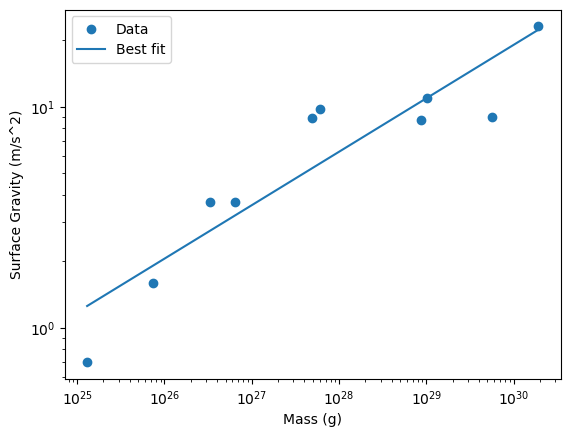

In [59]:
def linear_model(x, m, b):
    return m * x + b

x = np.array(mass_g)
y = np.array(gravity)

log_x = np.log10(x)
log_y = np.log10(y)

popt, pcov = curve_fit(linear_model, log_x, log_y)
m, b = popt

print("Best fit parameters:")
print("m =", m)
print("b =", b)

log_y_fit = linear_model(log_x, m, b)

residuals = log_y - log_y_fit
chi2 = np.sum(residuals**2)
dof = len(log_y) - len(popt)
reduced_chi2 = chi2 / dof

print("Reduced chi-squared =", reduced_chi2)

x_fit = np.linspace(x.min(), x.max(), 500)
log_x_fit = np.log10(x_fit)
log_y_line = linear_model(log_x_fit, m, b)
y_fit = 10**log_y_line

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_fit, y_fit, label="Best fit")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mass (g)")
plt.ylabel("Surface Gravity (m/s^2)")
plt.legend()
plt.show()

In [60]:
#The fit looks reaosnably good, the line does not hit all data points but it fits somewhere in the middle

In [61]:
df.to_csv("units.csv", index=False)